In [1]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold

import albumentations as A
from albumentations.pytorch import ToTensorV2

from monai.losses import TverskyLoss
from monai.losses import DiceLoss

from torch.utils.data import WeightedRandomSampler


import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt



device = (
    "cuda" if torch.cuda.is_available() 
    else "mps" if torch.backends.mps.is_available() 
    else "cpu"
)
print(f'Using device: {device}')

/home/fffeelipe/.conda/envs/torch_cuda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-03 16:00:49.046283: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-03 16:00:49.078778: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-03 16:00:49.937581: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see sli

Using device: cuda


In [2]:
# Define paths
DATA_DIR = './T1/'
IMAGE_DIR = './images/'
MASK_DIR = './masks/'

# Create directories if they don't exist
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(MASK_DIR, exist_ok=True)

# Get a list of patient folders
patient_folders = sorted(glob.glob(os.path.join(DATA_DIR, 'IOG*')))

In [3]:
import json

SLICE_MAP_PATH = 'slice_tumor_map.json'

def extract_and_save_slices(patient_folders, image_dir, mask_dir):
    """Extract slices and create a map tracking which have tumor segmentation."""
    slice_tumor_map = {}  # filename -> has_tumor (bool)
    
    for patient_folder in patient_folders:
        patient_id = os.path.basename(patient_folder)
        try:
            img_path = glob.glob(os.path.join(patient_folder, '*[!_roi].nii.gz'))[0]
            mask_path = glob.glob(os.path.join(patient_folder, '*_roi.nii.gz'))[0]

            img = nib.load(img_path).get_fdata()
            mask = nib.load(mask_path).get_fdata()

            # Normalize image to 0-255 and convert to uint8
            img = ((img - np.min(img)) / (np.max(img) - np.min(img)) * 255).astype(np.uint8)
            mask = (mask > 0).astype(np.uint8) * 255 # Binarize mask

            # Assuming axial slices are the last dimension
            for i in range(img.shape[2]):
                img_slice = Image.fromarray(img[:, :, i])
                mask_slice = Image.fromarray(mask[:, :, i])
                
                filename = f'{patient_id}_slice_{i}.png'
                has_tumor = bool(np.sum(np.array(mask_slice)) > 0)
                slice_tumor_map[filename] = has_tumor
                
                img_slice.save(os.path.join(image_dir, filename))
                mask_slice.save(os.path.join(mask_dir, filename))
                
        except IndexError:
            print(f'Skipping {patient_id} due to missing files.')
    
    # Save the map
    with open(SLICE_MAP_PATH, 'w') as f:
        json.dump(slice_tumor_map, f)
    
    pos = sum(slice_tumor_map.values())
    neg = len(slice_tumor_map) - pos
    print(f'Saved {len(slice_tumor_map)} slices: {pos} with tumor, {neg} without')
    return slice_tumor_map

slice_tumor_map = extract_and_save_slices(patient_folders, IMAGE_DIR, MASK_DIR)
print('Finished extracting and saving slices.')


Saved 1806 slices: 870 with tumor, 936 without
Finished extracting and saving slices.


Dataset balance: 870 positive, 936 negative slices


/tmp/ipykernel_79957/2384560237.py:11: UserWarning: Argument(s) 'shift_limit' are not valid for transform OpticalDistortion
  A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
/tmp/ipykernel_79957/2384560237.py:18: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),


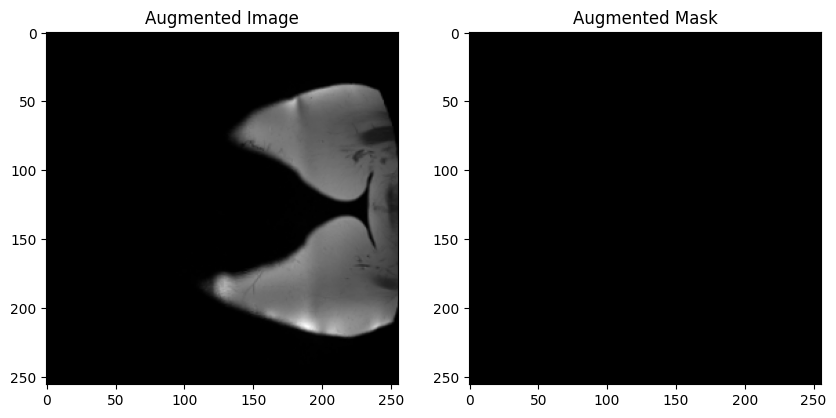

In [4]:
# This cell is now for the Dataset and Augmentations



# Define the augmentation pipeline for the training set
train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.GridDistortion(p=0.5),
    A.OpticalDistortion(p=0.5, distort_limit=1, shift_limit=0.5),
    A.Affine(
        rotate=(-15, 15),
        scale=(0.9, 1.1),
        translate_percent=0.05,
        p=0.75
    ),
    A.ElasticTransform(p=0.5, alpha=120, sigma=120 * 0.05, alpha_affine=120 * 0.03),
    A.RandomBrightnessContrast(p=0.5),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Define a simpler pipeline for the validation set (no augmentations)
val_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2(),
])

# Load the slice tumor map
def load_slice_tumor_map():
    if os.path.exists(SLICE_MAP_PATH):
        with open(SLICE_MAP_PATH, 'r') as f:
            return json.load(f)
    return {}

slice_tumor_map = load_slice_tumor_map()

class LipomaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, slice_tumor_map=None):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.slice_tumor_map = slice_tumor_map or {}
        
        # Build has_tumor flags for each sample
        self.has_tumor = []
        for img_path in self.image_paths:
            filename = os.path.basename(img_path)
            self.has_tumor.append(self.slice_tumor_map.get(filename, True))

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]
        
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Ensure mask is binary (0 or 255) before transformations
        mask = (mask > 0).astype(np.uint8) * 255

        if self.transform:
            transformed = self.transform(image=image, mask=mask)
            image = transformed['image']
            mask = transformed['mask']

        # Ensure mask tensor is binary (0 or 1) and has a channel dimension
        mask = (mask > 0.5).float().unsqueeze(0)

        return image, mask
    
    def get_balanced_sampler(self, neg_to_pos_ratio=1.0):
        """Create a WeightedRandomSampler to balance positive/negative samples.
        
        Args:
            neg_to_pos_ratio: Target ratio of negative to positive samples (1.0 = equal)
        """
        n_pos = sum(self.has_tumor)
        n_neg = len(self.has_tumor) - n_pos
        
        if n_pos == 0 or n_neg == 0:
            return None
        
        # Calculate weights: higher weight for minority class
        # For balanced sampling: weight_pos * n_pos = weight_neg * n_neg
        weight_pos = 1.0
        weight_neg = (n_pos / n_neg) * neg_to_pos_ratio
        
        weights = [weight_pos if has_tumor else weight_neg for has_tumor in self.has_tumor]
        
        return WeightedRandomSampler(
            weights=weights,
            num_samples=len(weights),
            replacement=True
        )

# Create a placeholder dataset to get all image/mask paths
all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.png')))
all_masks = sorted(glob.glob(os.path.join(MASK_DIR, '*.png')))

# Report balance
if slice_tumor_map:
    n_pos = sum(1 for img in all_images if slice_tumor_map.get(os.path.basename(img), True))
    n_neg = len(all_images) - n_pos
    print(f'Dataset balance: {n_pos} positive, {n_neg} negative slices')


# Demonstrate the augmentation by showing an example
if len(all_images) > 0:
    temp_dataset = LipomaDataset(image_paths=all_images, mask_paths=all_masks, 
                                  transform=train_transform, slice_tumor_map=slice_tumor_map)
    image, mask = temp_dataset[0]
    
    # Reverse normalization for visualization
    image = (image * 0.5) + 0.5
    
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image.squeeze(), cmap='gray')
    ax[0].set_title('Augmented Image')
    ax[1].imshow(mask.squeeze(), cmap='gray')
    ax[1].set_title('Augmented Mask')
    plt.show()


In [5]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(ConvBlock, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, features=[64, 128, 256, 512]):
        super(AttentionUNet, self).__init__()
        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Encoder
        for feature in features:
            self.encoder.append(ConvBlock(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = ConvBlock(features[-1], features[-1] * 2)

        # Decoder
        for feature in reversed(features):
            self.decoder.append(
                nn.ConvTranspose2d(feature * 2, feature, kernel_size=2, stride=2)
            )
            self.decoder.append(AttentionBlock(F_g=feature, F_l=feature, F_int=feature // 2))
            self.decoder.append(ConvBlock(feature * 2, feature))

        self.final_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def forward(self, x):
        skip_connections = []

        # Encode
        for i, down in enumerate(self.encoder):
            x = down(x)
            skip_connections.append(x)
            x = self.pool(x)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        # Decode
        # The decoder loop iterates in steps of 3: up-conv, attention, and conv-block.
        for i in range(0, len(self.decoder), 3):
            x = self.decoder[i](x) # Up-convolution
            skip_connection = skip_connections[i//3] # Get skip connection from encoder
            attention = self.decoder[i+1](g=x, x=skip_connection) # Apply attention
            x = torch.cat((attention, x), dim=1) # Concatenate
            x = self.decoder[i+2](x) # Double convolution

        return torch.sigmoid(self.final_conv(x))


# To reduce VRAM usage, you can decrease the number of features, e.g.:
# model = AttentionUNet(features=[64, 128, 256, 512]).to(device)
model = AttentionUNet(features=[64, 128, 256, 512]).to(device)

# Print model summary to check the architecture
print(model)                                                                                                                                 

AttentionUNet(
  (encoder): ModuleList(
    (0): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(inplace=True)
      )
    )
    (1): ConvBlock(
      (conv): Sequential(
        (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (5): ReLU(

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from scipy.ndimage import distance_transform_edt

class BoundaryLoss(nn.Module):
    """Boundary loss using distance transform."""
    def __init__(self):
        super().__init__()
    
    def compute_distance_map(self, mask):
        """Compute signed distance map: negative inside, positive outside."""
        mask_np = mask.cpu().numpy()
        batch_size = mask_np.shape[0]
        dist_maps = []
        
        for b in range(batch_size):
            m = mask_np[b, 0]
            if m.sum() == 0:  # Empty mask
                dist_maps.append(np.ones_like(m))  # All positive (penalize any prediction)
            else:
                # Negative inside (want pred=1), positive outside (want pred=0)
                pos_dist = distance_transform_edt(m)
                neg_dist = distance_transform_edt(1 - m)
                dist_map = neg_dist - pos_dist  # Flipped sign!
                # Normalize to [-1, 1] range
                dist_map = np.clip(dist_map / (np.abs(dist_map).max() + 1e-8), -1, 1)
                dist_maps.append(dist_map)
        
        return torch.tensor(np.stack(dist_maps), dtype=torch.float32, device=mask.device).unsqueeze(1)
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        dist_map = self.compute_distance_map(target)
        # Minimize: pred * dist_map (negative where we want pred=1, positive where pred=0)
        boundary_loss = (pred_sig * dist_map).mean()
        return boundary_loss

class DiceLoss(nn.Module):
    """Standard dice loss, handles empty masks."""
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        pred_flat = pred_sig.view(-1)
        target_flat = target.view(-1)
        
        intersection = (pred_flat * target_flat).sum()
        union = pred_flat.sum() + target_flat.sum()
        
        # Handle empty masks: if target is empty and pred is empty, dice=1
        if union < self.smooth:
            return 0.0  # Perfect prediction on empty mask
        
        dice = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1 - dice

class FocalLoss(nn.Module):
    """Focal loss for handling class imbalance."""
    def __init__(self, alpha=0.8, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
    
    def forward(self, pred, target):
        pred_sig = torch.sigmoid(pred)
        pred_flat = pred_sig.view(-1)
        target_flat = target.view(-1)
        
        bce = F.binary_cross_entropy(pred_flat, target_flat, reduction='none')
        pt = torch.exp(-bce)
        focal = self.alpha * (1 - pt) ** self.gamma * bce
        return focal.mean()

class CombinedLoss(nn.Module):
    """Dice + Focal + Boundary loss."""
    def __init__(self, dice_weight=0.5, focal_weight=0.3, boundary_weight=0.2):
        super().__init__()
        self.dice = DiceLoss()
        self.focal = FocalLoss()
        self.boundary = BoundaryLoss()
        self.dice_weight = dice_weight
        self.focal_weight = focal_weight
        self.boundary_weight = boundary_weight
    
    def forward(self, pred, target):
        d_loss = self.dice(pred, target)
        f_loss = self.focal(pred, target)
        b_loss = self.boundary(pred, target)
        
        total = self.dice_weight * d_loss + self.focal_weight * f_loss + self.boundary_weight * b_loss
        return total


In [7]:
# Hyperparameters
LEARNING_RATE = 5e-4
BATCH_SIZE = 8
NUM_EPOCHS = 50  # Increased since we have early stopping
NUM_FOLDS = 5
USE_BALANCED_SAMPLING = True
NEG_TO_POS_RATIO = 1.0
HOLDOUT_PATIENTS = 2  # Reserve N patients for final test
EARLY_STOP_PATIENCE = 7  # Stop if no improvement for N epochs
WARMUP_EPOCHS = 3

# Post-processing: keep largest connected component
def postprocess_mask(pred_mask):
    """Keep only the largest connected component."""
    from scipy import ndimage
    pred_np = pred_mask.cpu().numpy() if torch.is_tensor(pred_mask) else pred_mask
    
    processed = []
    for i in range(pred_np.shape[0]):
        mask = pred_np[i, 0] > 0.5
        if mask.sum() == 0:
            processed.append(mask.astype(np.float32))
            continue
        
        labeled, num_features = ndimage.label(mask)
        if num_features == 0:
            processed.append(mask.astype(np.float32))
            continue
            
        # Find largest component
        sizes = ndimage.sum(mask, labeled, range(1, num_features + 1))
        largest_label = np.argmax(sizes) + 1
        largest_mask = (labeled == largest_label).astype(np.float32)
        processed.append(largest_mask)
    
    return torch.tensor(np.stack(processed), device=pred_mask.device).unsqueeze(1)

# Test-Time Augmentation
def tta_predict(model, image):
    """Apply test-time augmentation: original + flips."""
    model.eval()
    with torch.no_grad():
        preds = []
        
        # Original
        preds.append(torch.sigmoid(model(image)))
        
        # Horizontal flip
        img_hflip = torch.flip(image, dims=[3])
        pred_hflip = torch.sigmoid(model(img_hflip))
        preds.append(torch.flip(pred_hflip, dims=[3]))
        
        # Vertical flip
        img_vflip = torch.flip(image, dims=[2])
        pred_vflip = torch.sigmoid(model(img_vflip))
        preds.append(torch.flip(pred_vflip, dims=[2]))
        
        # Both flips
        img_both = torch.flip(image, dims=[2, 3])
        pred_both = torch.sigmoid(model(img_both))
        preds.append(torch.flip(pred_both, dims=[2, 3]))
        
        # Average all predictions
        return torch.stack(preds).mean(dim=0)

# Cosine annealing with warmup scheduler
class WarmupCosineScheduler:
    def __init__(self, optimizer, warmup_epochs, total_epochs, min_lr=1e-6):
        self.optimizer = optimizer
        self.warmup_epochs = warmup_epochs
        self.total_epochs = total_epochs
        self.min_lr = min_lr
        self.base_lr = optimizer.param_groups[0]['lr']
        
    def step(self, epoch):
        if epoch < self.warmup_epochs:
            # Linear warmup
            lr = self.base_lr * (epoch + 1) / self.warmup_epochs
        else:
            # Cosine annealing
            progress = (epoch - self.warmup_epochs) / (self.total_epochs - self.warmup_epochs)
            lr = self.min_lr + 0.5 * (self.base_lr - self.min_lr) * (1 + np.cos(np.pi * progress))
        
        for param_group in self.optimizer.param_groups:
            param_group['lr'] = lr
        return lr

# Early stopping tracker
class EarlyStopping:
    def __init__(self, patience=7, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.should_stop = False
        
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0
        return self.should_stop

# Dice coefficient metric (separate from loss)
def dice_metric(pred, target, threshold=0.5):
    smooth = 1.0
    pred_bin = (torch.sigmoid(pred) > threshold).float()
    
    # Per-sample dice
    intersection = (pred_bin * target).sum(dim=(2, 3))
    pred_sum = pred_bin.sum(dim=(2, 3))
    target_sum = target.sum(dim=(2, 3))
    union = pred_sum + target_sum
    
    # Handle empty masks: if both pred and target empty, dice=1
    dice = (2. * intersection + smooth) / (union + smooth)
    
    # For empty targets where pred is also empty, set dice to 1
    empty_correct = ((target_sum == 0) & (pred_sum < 10)).float()  # Allow small noise
    dice = dice * (1 - empty_correct) + empty_correct
    
    return dice.mean()

# Training and Validation Functions
def train_epoch(loader, model, optimizer, loss_fn):
    model.train()
    total_loss = 0
    total_dice = 0
    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(images)
        loss = loss_fn(preds, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        total_dice += dice_metric(preds, masks).item()
    return total_loss / len(loader), total_dice / len(loader)

def validate_epoch(loader, model, loss_fn, use_tta=False, use_postprocess=False):
    model.eval()
    total_loss = 0
    total_dice = 0
    with torch.no_grad():
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)
            
            if use_tta:
                preds_sig = tta_predict(model, images)
                preds = torch.logit(preds_sig.clamp(1e-6, 1-1e-6))  # Convert back for loss
            else:
                preds = model(images)
            
            loss = loss_fn(preds, masks)
            
            if use_postprocess:
                preds_processed = postprocess_mask(torch.sigmoid(preds))
                total_dice += dice_metric(torch.logit(preds_processed.clamp(1e-6, 1-1e-6)), masks).item()
            else:
                total_dice += dice_metric(preds, masks).item()
            
            total_loss += loss.item()
    return total_loss / len(loader), total_dice / len(loader)

# Split patients: holdout test set + CV
patient_ids = sorted(list(set([os.path.basename(p).split('_slice_')[0] for p in all_images])))
np.random.seed(42)
np.random.shuffle(patient_ids)

# Reserve holdout patients
test_patients = patient_ids[:HOLDOUT_PATIENTS]
cv_patients = patient_ids[HOLDOUT_PATIENTS:]
print(f'Holdout test patients: {test_patients}')
print(f'CV patients: {cv_patients}')

# Create test set
test_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in test_patients]
test_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in test_patients]
test_dataset = LipomaDataset(image_paths=test_images, mask_paths=test_masks, 
                              transform=val_transform, slice_tumor_map=slice_tumor_map)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
print(f'Test set: {len(test_dataset)} slices from {len(test_patients)} patients')

# 5-Fold Cross-Validation on remaining patients
kf = KFold(n_splits=NUM_FOLDS, shuffle=True, random_state=42)
fold_results = []

criterion = CombinedLoss(dice_weight=0.4, focal_weight=0.4, boundary_weight=0.2)

for fold, (train_patient_indices, val_patient_indices) in enumerate(kf.split(cv_patients)):
    print(f'\n--- Fold {fold+1}/{NUM_FOLDS} ---')
    
    train_patients = [cv_patients[i] for i in train_patient_indices]
    val_patients = [cv_patients[i] for i in val_patient_indices]

    train_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in train_patients]
    train_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in train_patients]
    val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
    val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]

    train_dataset = LipomaDataset(image_paths=train_images, mask_paths=train_masks, 
                                   transform=train_transform, slice_tumor_map=slice_tumor_map)
    val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, 
                                 transform=val_transform, slice_tumor_map=slice_tumor_map)
    
    if USE_BALANCED_SAMPLING:
        sampler = train_dataset.get_balanced_sampler(neg_to_pos_ratio=NEG_TO_POS_RATIO)
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
        n_pos = sum(train_dataset.has_tumor)
        n_neg = len(train_dataset) - n_pos
        print(f'  Train: {len(train_dataset)} samples ({n_pos} pos, {n_neg} neg) - balanced')
    else:
        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    model = AttentionUNet(features=[96, 192, 384, 768]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    scheduler = WarmupCosineScheduler(optimizer, WARMUP_EPOCHS, NUM_EPOCHS)
    early_stopping = EarlyStopping(patience=EARLY_STOP_PATIENCE)

    history = {'train_loss': [], 'val_loss': [], 'train_dice': [], 'val_dice': [], 'lr': []}
    best_val_dice = -1.0

    for epoch in range(NUM_EPOCHS):
        lr = scheduler.step(epoch)
        train_loss, train_dice = train_epoch(train_loader, model, optimizer, criterion)
        val_loss, val_dice = validate_epoch(val_loader, model, criterion)

        print(f'Epoch {epoch+1}/{NUM_EPOCHS} | LR: {lr:.2e} | Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f} | Train Dice: {train_dice:.4f}, Val Dice: {val_dice:.4f}')
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_dice)
        history['val_dice'].append(val_dice)
        history['lr'].append(lr)
        
        if val_dice > best_val_dice:
            best_val_dice = val_dice
            torch.save(model.state_dict(), f'best_model_fold_{fold+1}.pth')
        
        if early_stopping(val_loss):
            print(f'  Early stopping at epoch {epoch+1}')
            break

    fold_results.append({
        'history': history, 
        'model_path': f'best_model_fold_{fold+1}.pth', 
        'val_patients': val_patients,
        'best_val_dice': best_val_dice
    })

print('\nFinished Cross-Validation.')

# Final evaluation on holdout test set with TTA and post-processing
print('\n=== Final Test Set Evaluation ===')
for fold_idx, result in enumerate(fold_results):
    model = AttentionUNet(features=[96, 192, 384, 768]).to(device)
    model.load_state_dict(torch.load(result['model_path']))
    
    # Without TTA/postprocess
    test_loss, test_dice = validate_epoch(test_loader, model, criterion, use_tta=False, use_postprocess=False)
    # With TTA + postprocess
    test_loss_tta, test_dice_tta = validate_epoch(test_loader, model, criterion, use_tta=True, use_postprocess=True)
    
    print(f'Fold {fold_idx+1}: Test Dice = {test_dice:.4f} | With TTA+PP = {test_dice_tta:.4f}')


Holdout test patients: ['IOG53', 'IOG4']
CV patients: ['IOG40', 'IOG7', 'IOG49', 'IOG55', 'IOG14', 'IOG21', 'IOG18', 'IOG12', 'IOG16', 'IOG39', 'IOG46', 'IOG31', 'IOG28', 'IOG22', 'IOG6', 'IOG26', 'IOG19', 'IOG27', 'IOG50', 'IOG45', 'IOG41', 'IOG1', 'IOG44', 'IOG43', 'IOG15', 'IOG20', 'IOG47', 'IOG10', 'IOG54', 'IOG35', 'IOG11', 'IOG48', 'IOG38', 'IOG5', 'IOG2', 'IOG36', 'IOG29', 'IOG9', 'IOG33', 'IOG17', 'IOG56', 'IOG24', 'IOG42', 'IOG51']
Test set: 38 slices from 2 patients

--- Fold 1/5 ---
  Train: 1425 samples (681 pos, 744 neg) - balanced
Epoch 1/50 | LR: 1.67e-04 | Train Loss: 0.5463, Val Loss: 0.5365 | Train Dice: 0.0213, Val Dice: 0.0210
Epoch 2/50 | LR: 3.33e-04 | Train Loss: 0.5307, Val Loss: 0.5253 | Train Dice: 0.0201, Val Dice: 0.0210
Epoch 3/50 | LR: 5.00e-04 | Train Loss: 0.5203, Val Loss: 0.5207 | Train Dice: 0.0214, Val Dice: 0.0210
Epoch 4/50 | LR: 5.00e-04 | Train Loss: 0.5192, Val Loss: 0.5195 | Train Dice: 0.0203, Val Dice: 0.0210
Epoch 5/50 | LR: 4.99e-04 | Train

KeyboardInterrupt: 

In [ ]:
# Plotting Training History
for i, result in enumerate(fold_results):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(result['history']['train_loss'], label='Train Loss')
    plt.plot(result['history']['val_loss'], label='Val Loss')
    plt.title(f'Fold {i+1} - Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(result['history']['train_dice'], label='Train Dice')
    plt.plot(result['history']['val_dice'], label='Val Dice')
    plt.title(f'Fold {i+1} - Dice Coefficient')
    plt.legend()
    plt.show()

# Displaying Qualitative Results from the best model of a fold
best_fold_idx = np.argmax([max(r['history']['val_dice']) for r in fold_results])
print(f"Showing results from Fold {best_fold_idx+1}, which had the best validation Dice score.")

# Load the best model from the best fold
best_model_path = fold_results[best_fold_idx]['model_path']
model = AttentionUNet(features=[64, 128, 256, 512]).to(device)
model.load_state_dict(torch.load(best_model_path))
model.eval()

# Get the validation data from that fold
val_patients = fold_results[best_fold_idx]['val_patients']
val_images = [img for img in all_images if os.path.basename(img).split('_slice_')[0] in val_patients]
val_masks = [mask for mask in all_masks if os.path.basename(mask).split('_slice_')[0] in val_patients]
val_dataset = LipomaDataset(image_paths=val_images, mask_paths=val_masks, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=3, shuffle=True)


with torch.no_grad():
    images, masks = next(iter(val_loader))
    images, masks = images.to(device), masks.to(device)
    preds = model(images)

    plt.figure(figsize=(15, 15))
    for i in range(3):
        plt.subplot(3, 3, i*3 + 1)
        plt.imshow(images[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Image')
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 2)
        plt.imshow(masks[i].cpu().squeeze(), cmap='gray')
        plt.title(f'Ground Truth')
        plt.axis('off')

        plt.subplot(3, 3, i*3 + 3)
        plt.imshow(preds[i].cpu().squeeze() > 0.5, cmap='gray')
        plt.title(f'Prediction')
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Cross-Validation Results Summary
print('--- Cross-Validation Results ---')
final_val_dices = [max(r['history']['val_dice']) for r in fold_results]
final_val_losses = [min(r['history']['val_loss']) for r in fold_results]

for i in range(NUM_FOLDS):
    print(f'Fold {i+1}: Best Val Loss = {final_val_losses[i]:.4f}, Best Val Dice = {final_val_dices[i]:.4f}')

print(f'Average Best Val Loss: {np.mean(final_val_losses):.4f} +/- {np.std(final_val_losses):.4f}')
print(f'Average Best Val Dice: {np.mean(final_val_dices):.4f} +/- {np.std(final_val_dices):.4f}')